### Description
This notebook runs dcfe two basins. Deliberately keeping things small, so as to enable testing and debugging.

In [1]:
from neuralhydrology.utils.config import Config
from neuralhydrology.utils.DCFE_utils import get_dcfe_params, filter_basins_all_param_files
from neuralhydrology.datautils import utils
from pathlib import Path
import torch
from neuralhydrology.nh_run import start_run

In [2]:
# Grab config file so we can see if the code works
#config_path = Path('/Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology/neuralhydrology/examples/07-DifferentialCFE-Model/2basinTest_devMultiBasin.yml')
config_path = Path('/home/ziyu/neuralhydrology/examples/07-DifferentialCFE-Model/2basinTest_devMultiBasin_HPC.yml')
config = Config(config_path, dev_mode=True)
basins = utils.load_basin_file(getattr(config, "train_basin_file"))

testDF = get_dcfe_params(config)
testDF.loc['02177000']
#testDF.loc['02349900']

depth                                                        tensor(2.)
bb                                                       tensor(1.8747)
satdk                                                    tensor(0.0007)
satpsi                                                   tensor(0.1889)
slop                                                     tensor(0.8340)
smcmax                                                   tensor(0.2987)
wltsmc                                                   tensor(0.0521)
D                                                            tensor(2.)
mult                                                         tensor(1.)
catchment_area_km2                                     tensor(111.1100)
refkdt                                                   tensor(0.8883)
max_gw_storage                                           tensor(0.2016)
expon                                                    tensor(1.8009)
Cgw                                                      tensor(

In [2]:
# by default we assume that you have at least one CUDA-capable NVIDIA GPU
if torch.cuda.is_available():
    print("GPU")
    start_run(config_file=Path("Test_devMultiBasin_HPC.yml"))

GPU
2025-08-13 14:03:19,331: Logging to /home/ziyu/neuralhydrology/examples/07-DifferentialCFE-Model/runs/DevMultiBasinHPC_Test_1308_140319/output.log initialized.
2025-08-13 14:03:19,332: ### Folder structure created at /home/ziyu/neuralhydrology/examples/07-DifferentialCFE-Model/runs/DevMultiBasinHPC_Test_1308_140319
2025-08-13 14:03:19,333: ### Run configurations for DevMultiBasinHPC_Test
2025-08-13 14:03:19,333: experiment_name: DevMultiBasinHPC_Test
2025-08-13 14:03:19,334: train_basin_file: basin_noSnow.txt
2025-08-13 14:03:19,334: validation_basin_file: basin_noSnow.txt
2025-08-13 14:03:19,335: test_basin_file: basin_noSnow.txt
2025-08-13 14:03:19,335: train_start_date: 2000-10-01 00:00:00
2025-08-13 14:03:19,336: train_end_date: 2014-09-30 00:00:00
2025-08-13 14:03:19,337: validation_start_date: 1990-10-01 00:00:00
2025-08-13 14:03:19,337: validation_end_date: 1996-09-30 00:00:00
2025-08-13 14:03:19,337: test_start_date: 1996-10-01 00:00:00
2025-08-13 14:03:19,338: test_end_dat

NoTrainDataError: 

2025-08-07 12:41:13,148: Using the model weights from runs/DevMultiBasinHPC_Test_0708_122512/model_epoch003.pt
# Evaluation:   0%|          | 0/2 [00:00<?, ?it/s]

Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:04<00:00,  2.04s/it]
2025-08-07 12:41:17,240: Stored metrics at runs/DevMultiBasinHPC_Test_0708_122512/test/model_epoch003/test_metrics.csv
2025-08-07 12:41:17,242: Stored results at runs/DevMultiBasinHPC_Test_0708_122512/test/model_epoch003/test_results.p


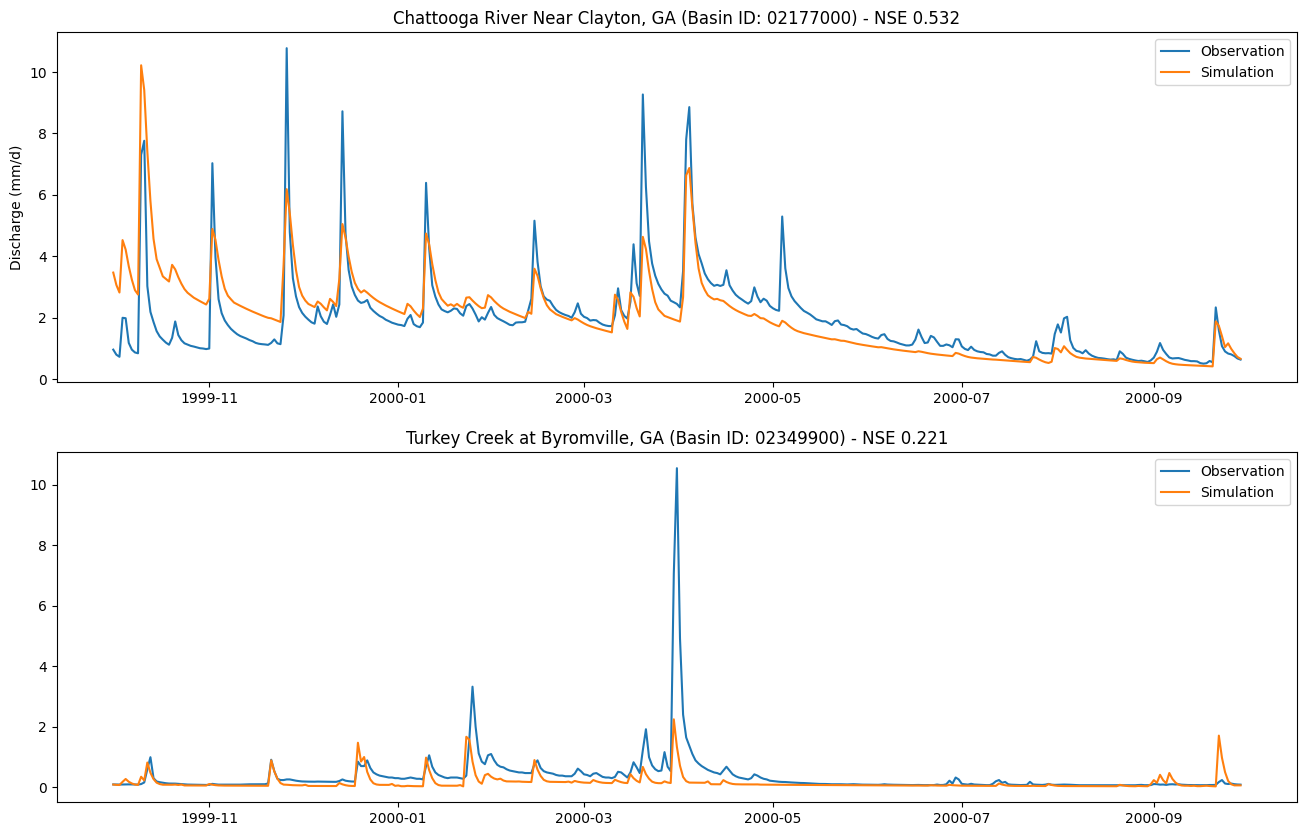

In [4]:
from neuralhydrology.evaluation import metrics, get_tester
import pandas as pd
from neuralhydrology.utils.config import Config
import matplotlib.pyplot as plt

run_dir = Path("runs/DevMultiBasinHPC_Test_0708_122512")
run_config = Config(run_dir/"config.yml")

# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="test", init_model=True)
results = tester.evaluate(save_results=True, metrics=run_config.metrics)

results.keys()

fig, ax = plt.subplots(2, 1, figsize=(16,10))

# Extract a date slice of observations and simulations
Result_xr = results['02177000']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar = Result_xr.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values = Result_xr.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr = Result_xr.assign_coords(datetime=("time_step", datetime_values))

# Extract observations and simulations
qobs = Result_xr['QObs(mm/d)_obs']
qsim = Result_xr['QObs(mm/d)_sim']

result_NSE = metrics.nse(qobs[0,:], qsim[0,:])
# Plot observations and simulations
ax[0].plot(Result_xr['datetime'], qobs[0,:], label="Observation")
ax[0].plot(Result_xr['datetime'], qsim[0,:], label="Simulation")
ax[0].set_ylabel("Discharge (mm/d)")
ax[0].set_title(f"Chattooga River Near Clayton, GA (Basin ID: 02177000) - NSE {result_NSE:.3f}")
_ = ax[0].legend()

# the other basin
# Extract a date slice of observations and simulations
Result_xr = results['02349900']['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar date and the 1D array of time_step values
date_scalar = Result_xr.coords['date'][0].values  # Extract as a NumPy scalar
time_step_values = Result_xr.coords['time_step'].values  # Extract as NumPy array

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
Result_xr = Result_xr.assign_coords(datetime=("time_step", datetime_values))

# Extract observations and simulations
qobs = Result_xr['QObs(mm/d)_obs']
qsim = Result_xr['QObs(mm/d)_sim']

result_NSE = metrics.nse(qobs[0,:], qsim[0,:])
# Plot observations and simulations
ax[1].plot(Result_xr['datetime'], qobs[0,:], label="Observation")
ax[1].plot(Result_xr['datetime'], qsim[0,:], label="Simulation")
ax[0].set_ylabel("Discharge (mm/d)")
ax[1].set_title(f"Turkey Creek at Byromville, GA (Basin ID: 02349900) - NSE {result_NSE:.3f}")
_ = ax[1].legend()
